## Lab 2: Differential Diagnosis and Conditional Expectation

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
import graphviz

# Load data
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
test = pd.read_csv('./data/ed_visits_probability_lab_test.csv')


A differential diagnosis is when a health care provider uses the availability of information about different symptoms to try to narrow down the set of possible health problems a patient might be experiencing, before recommending further testing or treatment.

We are not doctors, but we do have the National Hospital Ambulatory Medical Care Survey. The version we will use is **heavily** cleaned and simplified for our lab, please do not use it for research or any other purposes.

Here are the key pieces, in `./data/ed_visits_probability_lab_train.csv` and `./data/ed_visits_probability_lab_test.csv` files both contain:
- The patient's International Classification of Diseases (ICD) code has been simplified in the `disease_group` variable, with 18 categories like `cardiovascular` or `neurological`.
- There are binary symptoms: 'abdominal_pain', 'cough',
       'vomiting', 'fever', 'nausea', 'chest_pain', 'shortness_of_breath',
       'headache', 'accident', 'dizziness', 'back_pain', 'anxiety',
       'skin_rash'
- There are some other variables that likely have predictive value: `sex`, `arrival_by_ambulance`, and age group bins for under 20, 20-40, 40-60, 60-70, and over 70.

Note that you might have a skin rash because you have seborrheic dermatitis, and the underlying condition is actually Parkinson's Disease, which is neurological in nature. Likewise, a person who arrives in an ambulance with chest pain might be having a heart attack, but a walk-in with slight pain might be having an aortic dissection. Just because you have one kind of symptom that is representative of one class of diseases doesn't rule out complex or unexpected causes.

We are going to use the Decision Tree Classifier to learn more about conditional expectation. **This is not a lab about machine learning.** The decision tree classifier splits the sample according to questions about symptoms as it moves through the tree, and computes a probability mass function at each step that represents the proportions of the remaining part of the population with each of the disease codes.

## Step 1:

Run the code below, installing `scikit-learn` and `graphviz` as necessary.

In [4]:
# Symptom variables
symptoms = [
    'abdominal_pain', 'cough', 'vomiting', 'fever', 'nausea',
    'chest_pain', 'shortness_of_breath', 'headache', 'accident',
    'dizziness', 'back_pain', 'anxiety', 'skin_rash',
]

# Patient-context variables
patient_vars = [
    'arrival_by_ambulance', 'sex',
    'age_u20', 'age_20_40', 'age_40_60', 'age_60_70', 'age_o70',
]

x_vars = symptoms + patient_vars

# Explanatory-variable matrices
X = df[x_vars].to_numpy()
X_test = test[x_vars].to_numpy()

print('Disease groups:')
print(df['disease_group'].value_counts())


Disease groups:
disease_group
injury_trauma               17711
general_constitutional       8048
other                        5924
ear_nose_throat_eye          4800
gastrointestinal             3911
genitourinary_renal          3796
respiratory                  3688
psychiatric_behavioral       3637
musculoskeletal              3430
infectious_disease           2988
cardiovascular               2320
endocrine_metabolic          2012
dermatologic                 1811
injury_adverse_care          1511
neurological                 1270
pregnancy_related            1237
injury_poisoning              779
hepatobiliary_pancreatic      618
Name: count, dtype: int64


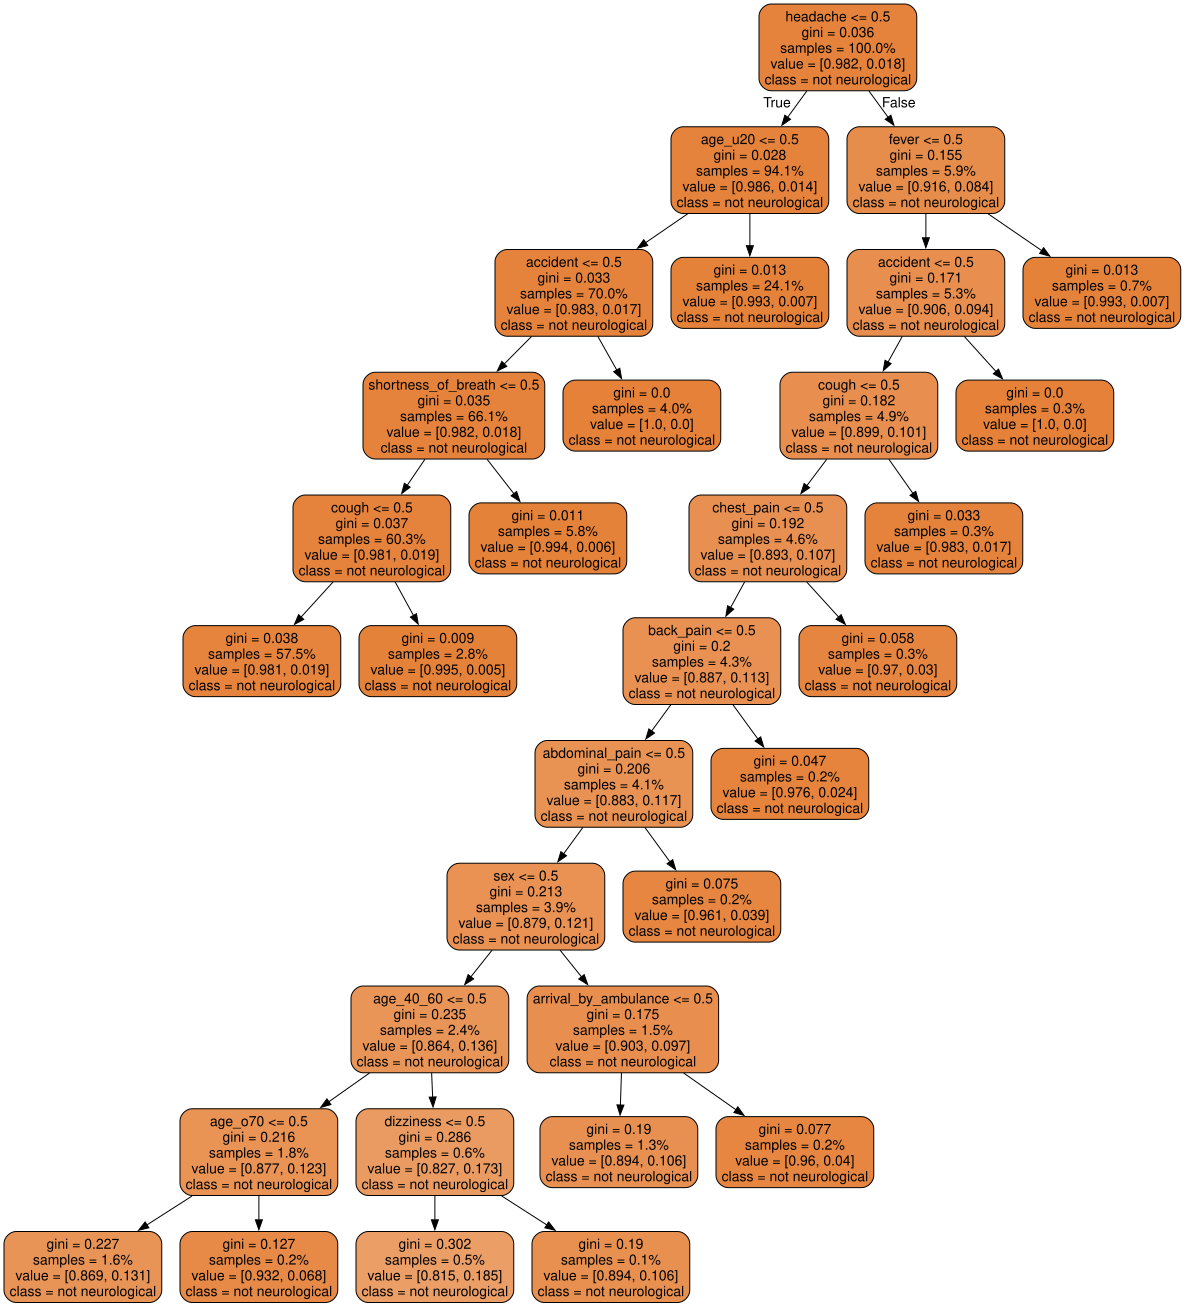

In [5]:
# Set outcome variable:
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-5, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

The above object is a **decision tree classifier**: It predicts class labels on the basis of covariates. At each **node** in the graph, there is a condition, like `cough<=.5`. Depending on how the case evaluates, we move left (`True`) or right (`False`) down the tree along the **edges**. At each node, we also see the probability mass function, conditional on the current information set. At the bottom of the tree are **terminal leaves** with hard classification predictions and the final proportions.

The tree classifier pictured in the previous code chunk provides the probability mass function over the labels "not respiratory" and "respiratory". It starts as 95% of patients not having a respiratory problem, and 5% having a respiratory problem. The first differential diagnosis question is, "Does the patient have a cough?" If they do have a cough, we update our estimate to .73/.27, and if not, we update to .97/.03. If you have a cough, shortness of breath, you reach the highest estimate, .59/.41.

This is exactly what conditional probability and conditional expectation are: We update our beliefs based on evidence, and that reshapes our posterior estimates of the probabilities of different outcomes.

The probabilities displayed by the tree are fitted conditional estimates: they are the training-data class proportions among patients reaching each node. They are useful for this lab, but they are not calibrated clinical risk estimates.

<div class="alert alert-block alert-warning">

Which combinations of symptoms make a respiratory disease the most likely explanation? The least likely?

Which variables does the tree exploit? 

Clearly explain how the tree is a representation of conditional updating, where we condition on reported symptoms to provide new probability estimates based on new information.

Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?

</div>

A combination of no cough, no shortness of breath, and no fever is the combination of symptoms that make a respiratory disease the least likely, with an estimated 98% of patients not having a respiratory disease. A patient with a cough and shortness of breath makes a respiratory disease the most likely explanation, with an estimate of 58%.

The tree exploits the cough and shortness of breath variables, as both of these are the most likely predictors of a respiratory disease.

The tree updates its probabilities of respiratory disease based on the answer to the previous responses. Each branch changes the variables involved, and thus changes the probability of disease.

1e-3:
Lowest: 2.2% when the patient has no cough or shortness of breath.

Highest: 27.5% when the patient has a cough.

1e-5:
Lowest: 0.0% when the patient has no cough, shortness of breath, fever, chest pain, and was in an accident.

Highest: 55.5% when the patient has a cough and shortness of breath, no chest pain, no headache, and is over 70 years old and male.

1e-7:
Lowest: There are many outcomes for a 0.0% probability of a respiratory infection. One such case is when the patient has no cough, no shortness of breath, a fever, no abdominal pain, a skin rash, and is male.

Highest: 57.7% when the patient has a cough, shortness of breath, no chest pain, no headache, is over 70 years old, male, and did not arrive by ambulance.


As the tree gets more complex, the probabilities for both repiratory disease and non-respiratory disease increase.

<div class="alert alert-block alert-warning">

Repeat the previous step with `disease = 'neurological'` and `min_impurity_decrease = 1e-3`. What variables are used in the tree? Which variables raise or lower the predicted probability of a neurological diagnosis?

</div>

When using min_impurity_decrease = 1e-3, the tree only contains one node, so I used a value of 1e-5.The variables used in the tree are headache, age, fever, accident, cough, shortness of breath, chest pain, back pain, abdominal pain, sex, arrival by ambulance, and dizziness. Of these, only sex, age, and headache raise the probability of a neurological diagnosis.

## Step 2:

In step 1, we tried to predict whether a patient has a single condition or not. Now, we want to predict the entire probability mass function.

The code block sets `y = df['disease_group']` and `outcome = df['disease_group'].unique()`, and runs a similar analysis. The result is now a fitted differential diagnosis: an estimated probability mass function over the labels and a hard classification label. For readability, we set `max_depth = 3`.

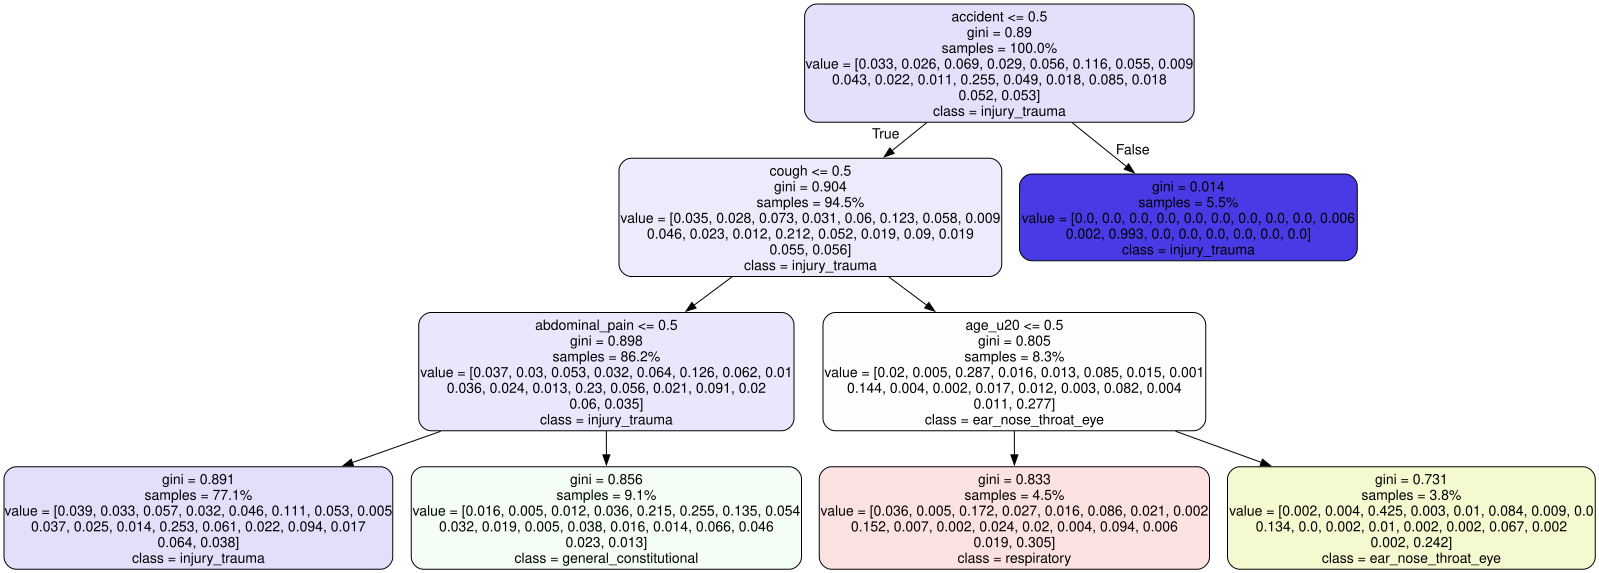

In [6]:
# Set outcome variable:
y = df['disease_group']
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 3, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)


# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=model.classes_,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

Which diseases are predicted as hard classifications in the tree? For those labels, does the probability of that disease exceed even a moderate value like .3 or .5, or not? Why might this be a concern?

Which labels have the highest or lowest probabilities for the predicted disease class labels? 

Which conditions and values are used in the tree?

Even if the probabilities for each terminal leaf remain fairly small in absolute terms, why can a differential diagnosis tool like this still be useful for doctors?

</div>

The diseases predicted as hard classifications are "ear_nose_throat_eye" and "respiratory". The maximum probabilities in leaves where these diseases are present are between 28.7% and 42.5%. The low probability could be a concern for doctors trying to diagnose using this tree because the cost of misdiagnosis is severe, and a tree that has a maximum probability of 42.5% is not very reliable for diagnosing.

The disease class labels are closely interlinked, as the "ear_nose_throat_eye leaves" have the highest probability of ear, nose, throat, or eye disease and a second highest probability of respiratory disease. The inverse holds true as well, as the "respiratory" leaf has the highest probability of respiratory disease, and the second highest probability of ear, nose, throat or eye disease. All leaves have a low probability of all other disease classes, with the lowest being 'hepatobiliary_pancreatic' and 'injury_poisoning'.

The conditions used in the tree begin with whether or not the patient has been in an accident. If the patient has not been in an accident, the tree branches to the cough leaf, and from there splits to abdominal pain and age < 20 leaves. 

Differential diagnosis trees such as this one can be useful to doctors despite the small probabilites by providing insight into the condition of the patient. Using these trees, doctors can see preliminary suggestions and work from there, hopefully leading to quicker and more accurate diagnoses. However, using the tree can also be detrimental if doctors rely too heavily on its results. Overreliance on the trees could cause the doctor to focus on one or two specific symptoms, leading to potential misdiagnosis. So long as the trees are used as an aid and not the basis for a diagnosis, even trees with low probability outcomes can help doctors deliver prompt diagnoses to their patients.